# Logistic Regression

Logistic regression is a supervised machine learning algorithm primarily used for binary classification tasks.
It predicts the probability of an outcome being true or false, represented as 1 or 0, based on input features. 
The algorithm models the probability that a given input belongs to a particular class, allowing for the prediction of binary outcomes. 

In [2]:
#importing the necessary libraries

import numpy as np
import pandas  as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [3]:
#Example data

data = {
    'Hours_Studied' : [1,2,3,4,5,6,7,8,9,10],
    'Passed' : [0,0,0,0,1,1,1,1,1,1]
}


In [4]:
df = pd.DataFrame(data)

In [5]:
df

,Hours_Studied,Passed
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1


In [6]:
# independent variable (feature) and dependent variable (target)

X = df[['Hours_Studied']]
Y = df['Passed']

In [7]:
X,Y

(   Hours_Studied
 0              1
 1              2
 2              3
 3              4
 4              5
 5              6
 6              7
 7              8
 8              9
 9             10,
 0    0
 1    0
 2    0
 3    0
 4    1
 5    1
 6    1
 7    1
 8    1
 9    1
 Name: Passed, dtype: int64)

In [8]:
#Splitting the data into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [9]:
X_train

,Hours_Studied
4,5
9,10
1,2
6,7
7,8
3,4
0,1
5,6


In [10]:
X_test

,Hours_Studied
2,3
8,9


In [11]:
Y_train

4    1
9    1
1    0
6    1
7    1
3    0
0    0
5    1
Name: Passed, dtype: int64

In [12]:
Y_test

2    0
8    1
Name: Passed, dtype: int64

In [14]:
model = LogisticRegression()
model

LogisticRegression()

In [15]:
model.fit(X_train, Y_train)

LogisticRegression()

In [16]:
# Making the predictions

Y_pred = model.predict(X_test)

In [17]:
Y_pred

array([0, 1], dtype=int64)

In [20]:
Y_pred_prob = model.predict_proba(X_test)[:,1]
Y_pred_prob

array([0.19925014, 0.99371007])

In [24]:
#Evaluating the model

conf_matrix = confusion_matrix(Y_test, Y_pred)
class_report = classification_report(Y_test, Y_pred)
roc_auc = roc_auc_score(Y_test, Y_pred)

print(f"Confusion matrix      : \n {conf_matrix}")
print(f"classification Report : \n {class_report}")
print(f"ROC-AUC               :\n {roc_auc}")

Confusion matrix      : 
 [[1 0]
 [0 1]]
classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

ROC-AUC               :
 1.0


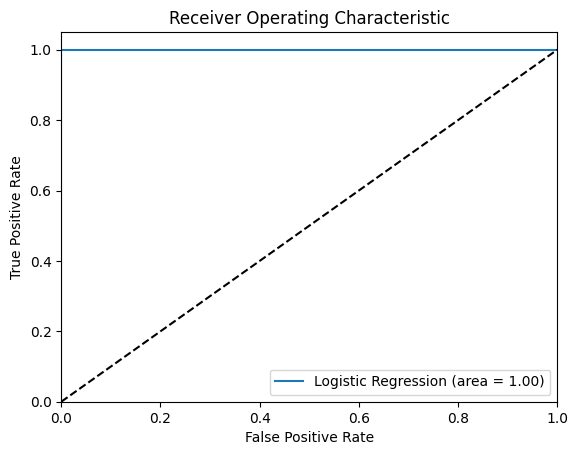

In [27]:
#plotting the ROC CURVE

fpr, tpr, thresholds = roc_curve(Y_test,Y_pred_prob)
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)'%roc_auc)

plt.plot([0,1],[0,1], 'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()